# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Harriet Yayra Boven Fiahagbe
**Student ID:** 59722028

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [36]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

In [37]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
# taxi = pd.read_csv(...)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.


In [38]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it

taxi.shape
taxi.head()
taxi.info()
taxi.describe()
taxi.isna().sum()

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


In [39]:
taxi.shape #Checking the number of rows and cols

(41202, 13)

In [40]:
#taxi.head()
taxi

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41197,2,1,16.94,2,1,132,164,1,70.0,0.5,6.94,1,5.00
41198,2,4,19.83,2,1,132,166,1,70.0,0.5,6.94,1,8.00
41199,2,1,17.31,2,1,132,137,1,70.0,0.5,6.94,1,8.00
41200,2,1,17.28,2,1,132,233,1,70.0,0.5,6.94,1,16.19


In [41]:
taxi.info() #Getting a summarized information about the Taxi dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


In [42]:
taxi.describe().T#Seeing the analysis of each col/attribute, .T was used to chnage the positions of the rows and cols to a person preference

,count,mean,std,min,25%,50%,75%,max
VendorID,41202.0,2.000000,0.000000,2.00,2.00,2.00,2.00,2.00
passenger_count,41202.0,1.633926,0.924250,1.00,1.00,1.00,2.00,8.00
trip_distance,41202.0,18.384928,2.856605,0.00,17.37,18.18,19.38,189.91
RatecodeID,41202.0,2.025411,0.461587,1.00,2.00,2.00,2.00,5.00
store_and_fwd_flag,41202.0,0.999393,0.024625,0.00,1.00,1.00,1.00,1.00
PULocationID,41202.0,132.220475,7.726159,10.00,132.00,132.00,132.00,264.00
DOLocationID,41202.0,164.546333,67.901529,3.00,113.00,163.00,231.00,265.00
payment_type,41202.0,1.000000,0.000000,1.00,1.00,1.00,1.00,1.00
fare_amount,41202.0,69.986150,6.184851,3.70,70.00,70.00,70.00,199.70
mta_tax,41202.0,0.491020,0.066404,0.00,0.50,0.50,0.50,0.50


In [43]:
taxi.isna().sum() #Check the number of missing values

,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


0
76
0


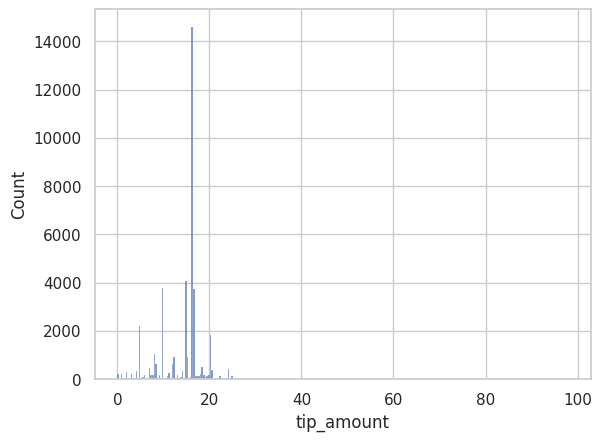

In [44]:
#Visualizing the distribution of the tip amount using a histogram
sns.histplot(taxi['tip_amount'])

print((taxi["tip_amount"]< 0).sum())

print((taxi["trip_distance"]<= 0).sum())

print((taxi["fare_amount"]<= 0).sum())

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:**



The histogram shows that its shape can be considered right-skewed as most values are populated on the left-hand side of the graph, while there is a long tail stretching on the right. Also, the graph does not show any extreme values or outliers in the tip_amount column, which we may say may look reasonably distributed, but does not confirm that the whole dataset is clean.


The shape of the taxi data shows that there are 41202 rows and 13 columns in the whole set. There are no missing values in this set, yet there are 76 rows that have been flagged to have a trip_distance of less than 0 in the dataset, while 0 negative tip_amounts are also recoded. As said above, the tip_amount is right-skewed, which means most data are populated on the left-hand side, with a long tail stretching to the right. This means there is a tendency that the mean is greater than the median, and the median is greater than the mode, in the tip_amount set of information. There are no outliers identified in the tip_amount column,  nonetheless, there is a spike of 16, which connects to the inconsistencies in the trip_distance and the fare_amount, as the data seem to be clustered and unrealistic. From the information gathered, in our preprocessing, we are likely to drop some constant columns, including payment_type, vendorID, and find more information with columns that have clustered data and are sensitive to outliers and extreme values.


### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [45]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)


In [46]:
#Dropping rows that are less than or equal to 0 in trip_ distance
taxi = taxi[taxi["trip_distance"] >0]

#Checking to see if all rows less than 0 have been removed
print((taxi["trip_distance"]<= 0).sum())


#Dropping both VendorID and payment_type since they have a std of 0 showing no variation betweent the data, instead shows that all the values are very much identical
#taxi = taxi.drop(columns=['VendorID','payment_type'])

taxi.shape
taxi.columns

0


Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type',
       'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge',
       'tip_amount'],
      dtype='object')

In [47]:
#Using the feature Total Surcharges
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']

#Check if the total surcarges created accurately, by returning the first five rows
taxi[['total_surcharges','mta_tax' , 'tolls_amount' , 'improvement_surcharge']].head()




/tmp/ipykernel_689/2563964202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']


,total_surcharges,mta_tax,tolls_amount,improvement_surcharge
0,8.44,0.5,6.94,1
1,8.44,0.5,6.94,1
2,8.44,0.5,6.94,1
3,1.50,0.5,0.00,1
4,8.44,0.5,6.94,1


In [48]:
# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

#Encoding the categorical cols
categorical_cols = [
    'VendorID',
    'RatecodeID',
    'payment_type',
    'store_and_fwd_flag'
]

encoded_values = pd.get_dummies(taxi, columns = categorical_cols, drop_first= True)

#Checking if encoded values and main values in taxi are the same
print(f"Actual Shape: {taxi.shape}")
print(f"Encoded Shape: {encoded_values.shape}")


# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
#Importing sklearn.preprocessing

from sklearn.preprocessing import StandardScaler



Actual Shape: (41126, 14)
Encoded Shape: (41126, 14)


**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:**

The dataset had no missing values. There were 76 rows with the column trip distance less than or equal to 0 which was dropped, because in our datase twe cant have a taxi trip with a zero or negative distance, since noise may be introduced in the model if not eliminated.
I engineered the total_surcharges feature, which was created by adding mta_tax, tolls_amount, and imporvement_surcharge. The intuition behind this was that the total additional charges on a trip may inflence how much money a passenger would tip, as higher surchrages increase the overall bill paid.
The StandardScaler was used, where its job is to scale each feature to have a mean of 0, and a standard deviation of 1. This is useful here as the numeric features in the dataset may have different scales, and the StandardScaler ensures that no single features dominates the model.








### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [49]:
# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)


In [50]:
#Seperating features X and target Y
X= encoded_values.drop(columns=['tip_amount'])
y = encoded_values['tip_amount']


from sklearn.model_selection import train_test_split

#First split off the test set (20% of the whole dataset)
X_temp, X_test, y_temp, y_test = train_test_split(
   X, y,
   test_size = 0.2,
   random_state = RANDOM_STATE)

#Second split: split the rest fo the 80% temp into 60% train and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size = 0.25,
    random_state = RANDOM_STATE)

#printing the shape of X, val, train and test
print(f"Current Train: {X_train.shape}, Val: {X_val.shape}, Test:{X_test.shape}")


# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)

#Tranforming the train, val, test using the scaler fitted on the training dateset we are using
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Current Train: (24675, 13), Val: (8225, 13), Test:(8226, 13)


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*


> **Answer:**


In splitting we did a 60/20/20 split where 60% was used for traning, 20% for validation and 20% for testing. For this dataset, a seperate validation set is useful is because its allows hyperparameter tuning and model selection without touching the test set, keeping the test set  unseen, which is a honest final evaluation. If we decided to use the test set for tuning, the score gotten would not be a reliable and accurate measure of the real-world performace, therefore the scaler must be fit on the training data only. This is because fitting on the validation would leak information  about unseen data into the model.


### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

In [51]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

# TODO: Predict on train, validation, and test sets.

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).



Linear Regression Results: 
Validation RMSE: 5.037, R^2: 0.049
Test RMSE: 5.013, R^2: 0.051
Train RMSE: 4.805, R^2: 0.051

Decision Tree Results: 
Validation RMSE: 6.763, R^2: -0.715
Test RMSE: 6.821, R^2: -0.757
Train RMSE: 2.382, R^2: 0.767


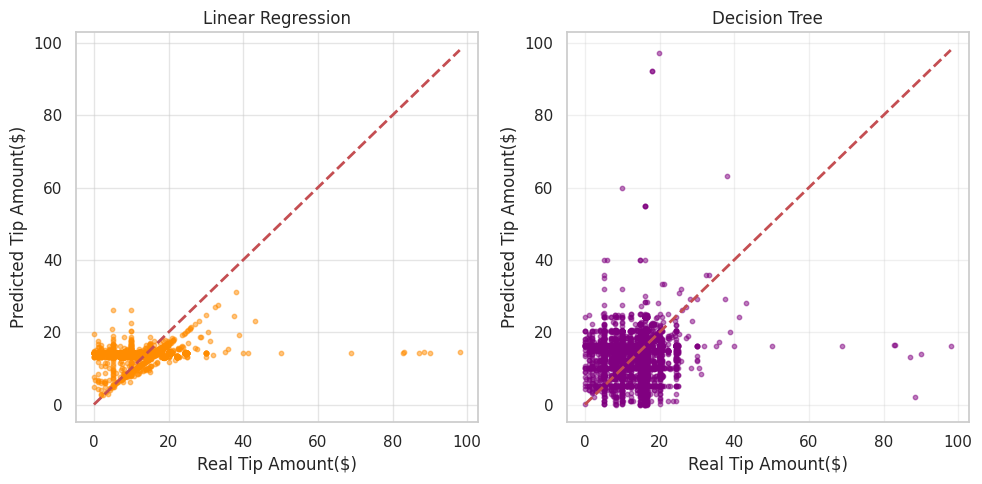

In [52]:
#Importing the required models needed

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error , r2_score
import numpy as np
import matplotlib.pyplot as plt

#Initializing and training a regression model using linear regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled,y_train)

#Predict on train, validation and test data sets
linear_val_prediction = linear_model.predict(X_val_scaled)
linear_test_prediction = linear_model.predict(X_test_scaled)
linear_train_prediction = linear_model.predict(X_train_scaled)

#Evaluating and reporting RMSE and R^2 for all the three sets
linear_val_rmse = np.sqrt(mean_squared_error(y_val, linear_val_prediction))
linear_test_rmse = np.sqrt(mean_squared_error(y_test, linear_test_prediction))
linear_train_rmse = np.sqrt(mean_squared_error(y_train, linear_train_prediction))


linear_val_r2 = r2_score(y_val,linear_val_prediction)
linear_test_r2 = r2_score(y_test,linear_test_prediction)
linear_train_r2 = r2_score(y_train,linear_train_prediction)

#Printing all necessary Information
print("\nLinear Regression Results: ")
print(f"Validation RMSE: {linear_val_rmse:.3f}, R^2: {linear_val_r2:.3f}")
print(f"Test RMSE: {linear_test_rmse:.3f}, R^2: {linear_test_r2:.3f}")
print(f"Train RMSE: {linear_train_rmse:.3f}, R^2: {linear_train_r2:.3f}")


#Initializing and training a regression model using Decision Tree
dtree_model= DecisionTreeRegressor(random_state=RANDOM_STATE)
dtree_model.fit(X_train_scaled,y_train)

#Predict on train, validation and test data sets
dtree_val_prediction = dtree_model.predict(X_val_scaled)
dtree_test_prediction = dtree_model.predict(X_test_scaled)
dtree_train_prediction = dtree_model.predict(X_train_scaled)

#Evaluating and reporting RMSE and R^2 for all the three sets
dtree_val_rmse = np.sqrt(mean_squared_error(y_val, dtree_val_prediction))
dtree_test_rmse = np.sqrt(mean_squared_error(y_test, dtree_test_prediction))
dtree_train_rmse = np.sqrt(mean_squared_error(y_train, dtree_train_prediction))


dtree_val_r2 = r2_score(y_val,dtree_val_prediction)
dtree_test_r2 = r2_score(y_test,dtree_test_prediction)
dtree_train_r2 = r2_score(y_train,dtree_train_prediction)

#Printing all necessary Information
print("\nDecision Tree Results: ")
print(f"Validation RMSE: {dtree_val_rmse:.3f}, R^2: {dtree_val_r2:.3f}")
print(f"Test RMSE: {dtree_test_rmse:.3f}, R^2: {dtree_test_r2:.3f}")
print(f"Train RMSE: {dtree_train_rmse:.3f}, R^2: {dtree_train_r2:.3f}")


#Plotting the Graphs


fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))

#Linear Regression Model

ax1.scatter(y_test,linear_test_prediction, alpha = 0.5 ,s=10, color='darkorange')
ax1.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
ax1.set_xlabel("Real Tip Amount($)")
ax1.set_ylabel("Predicted Tip Amount($)")
ax1.set_title("Linear Regression")
ax1.grid(True, alpha = 0.5)

#Decision Tree Model

ax2.scatter(y_test,dtree_test_prediction, alpha = 0.5 ,s=10, color='purple')
ax2.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
ax2.set_xlabel("Real Tip Amount($)")
ax2.set_ylabel("Predicted Tip Amount($)")
ax2.set_title("Decision Tree")
ax2.grid(True, alpha = 0.3)


plt.tight_layout()
plt.show()

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:**


Linear Regression performed best on the validation set because it had an R^2 score of 0.049 compared to the decision tree which had a validation R^2 of -0.715.

I used max_depth for the Decision treehyperparameter Regression had an RMSE of 4.805  and R^2 score of 0.051 for the train, an RMSE of 5.037 and R^2 score of 0.049 for validation and an RMSE of 5.013 and R^2 score of 0.051 for test.The RMSE for all is approximately 5 and the R^2 score for all is approximately 0.This indicates linear regression model is underfitting.  For Decision Tree, it had an RMSE of 2.382  and R^2 score of 0.767 for the train, an RMSE of 6.763 and R^2 score of  -0.715 for validation and an RMSE of  6.821 and R^2 score of -0.757 for test.This shows that this model is overfitting becauses there is a large difference between the training performance and test performance, implying that it memorised the training data but did not generalise it.

To reduce overfitting , I would use Random Forest since it finds the average of many decision trees to reduce overfitting. I could also reduce the max_depth(hyperparameter) to 3 -5 this would make the tree implement pruning.


---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

In [53]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`

# TODO: Inspect shape, head, info, describe, and missing values.

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

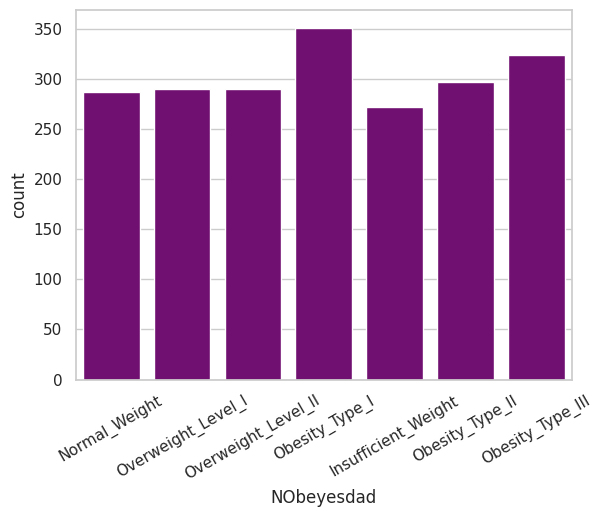

In [54]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv')


# TODO: Inspect shape, head, info, describe, and missing values.
obesity.shape


obesity.head()

obesity.info()


obesity.describe()

obesity.isna().sum()

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print(obesity["NObeyesdad"].value_counts())


#The countplot graph
sns.countplot(data=obesity, x= "NObeyesdad", color= 'purple')
plt.xticks(rotation= 30)
plt.show()

**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:**


There are 2111 rows and 17 columns in total for this dataset.

Numerical cols; Age, Weight, FCVC,NCP,CH20,FAF,TUE,Height

Categorical cols;gender, family_history_with_overweight, FAVC, CAEC, Smoke, SCC, CALC, MTRANS,Nobeyesdad

None of the columns have missing values.

The target NObeyesdad can be said to be fairly balanced as the class counts ranged from 272 to 351, which is roughly similar across all 7 classes. The class balance matters as imbalanced classes can be bias toward a model, causing under fitting. However since this dataset is a balanced one accuracy should be a reasonably reliable metric.




### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [55]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).


In [56]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
obesity = pd.read_csv(OBESITY_URL)
#Encoding the categorical columns
obesity['family_history_with_overweight'].unique()
obesity['FAVC'].unique()
obesity['SMOKE'].unique()
obesity['SCC'].unique()

binary_mapping = {"yes": 1, "no":0}

obesity['family_history_with_overweight'] = obesity['family_history_with_overweight'].map(binary_mapping)
obesity['FAVC'] = obesity['FAVC'].map(binary_mapping)
obesity['SMOKE'] = obesity['SMOKE'].map(binary_mapping)
obesity['SCC'] = obesity['SCC'].map(binary_mapping)


# - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
print(obesity['CAEC'].unique())
print(obesity['CALC'].unique())


ordinal_mapping = {"no":0, "Sometimes":1, "Frequently":2, "Always":3 }
obesity['CAEC'] = obesity['CAEC'].map(ordinal_mapping)
obesity['CALC'] = obesity['CALC'].map(ordinal_mapping)


#Encoding Nominal values
obesity['Gender'].unique()
obesity['MTRANS'].unique()

obesity = pd.get_dummies(obesity, columns=['MTRANS', 'Gender'], drop_first=True)



# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity['BMI'] = obesity['Weight']/(obesity['Height'] **2)
obesity[['Height', 'Weight', 'BMI']].head()
#From the values, BMI does not leak the values because it is not calculated using the target which is the NObeyesdad. It is just calculated with Height and Weight, nonetheless this can make the algorithm
#too easy which may cause underfitting because there are too related to each other.

# TODO: Encode the target `NObeyesdad` into integer class labels

from sklearn.preprocessing import LabelEncoder

main_encoder = LabelEncoder()

obesity["NObeyesdad"] = main_encoder.fit_transform(
    obesity["NObeyesdad"]
)


obesity["NObeyesdad"].head()

#Creating out X and y

y = obesity["NObeyesdad"]

X= obesity.drop("NObeyesdad",axis =1)

print(obesity.isna().sum()[obesity.isna().sum() > 0])


# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
from sklearn.preprocessing import StandardScaler

['Sometimes' 'Frequently' 'Always' 'no']
['no' 'Sometimes' 'Frequently' 'Always']
Series([], dtype: int64)


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:**

I encoded the categorical variables with binary yes or no columns were they were directly mapped to 0 or 1 since there only have two possible values (family_history_with_overweight, FAVC, SMOKE, SCC), CAEC, CALC) have a natural order there i used the "ordrinalencoder" in order to preserve that ranking. Lasting for Gender and MTRANS, since there has no natural order, i used a one hot encoding to help avoid implying false ranking between the categories.

I engineered the BMI which is weight/ height **2. This is a defensible feature to keep as it is legitimate, and has a strong predictor since BMI is a real and reliable physical measurement yet it should be flagged as in the long run it may be helping to make the tasks easier. In addition this could be risky, as since obesity level is medically defined using the BMI features, the model could easily learn to reverse-engineer the target from the BMI rather than learning true patterns from eating or acting habits.

I used a StandardScaler fi on the training set only, as the number features are on a very different scales and many models usually perform better when features are standardized to 0 mean and unit variance.


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [57]:
# TODO: Separate X (features) and y (encoded NObeyesdad).

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

# TODO: Fit the scaler on the training set only, then transform train / val / test.


In [58]:
# TODO: Separate X (features) and y (encoded NObeyesdad).

X= obesity.drop('NObeyesdad' , axis=1)
y = obesity['NObeyesdad']


from sklearn.model_selection import train_test_split

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.

#First split off the test set (20% of the whole dataset)
X_temp, X_test, y_temp, y_test = train_test_split(
   X, y,
   test_size = 0.2,
   stratify=y,
   random_state = RANDOM_STATE)

#Second split: split the rest fo the 80% temp into 60% train and 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size = 0.25,
    stratify=y_temp,
    random_state = RANDOM_STATE)


# TODO: Fit the scaler on the training set only, then transform train / val / test.
from sklearn.preprocessing import StandardScaler


#Fitting on train obly
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:**

I used a 60/20/20 train/validation/test split. stratify = y is important for this dataset because the target has 7 classes and if we stratify ,it would ensure that each split for the train,val and test would have the same proportion of each class just like the full dataset.

If I split without stratifying, random splitting would be done and some classes would be underrepresented, overrepresented or even be left out from the split and this would make the evaluation metrics unreliable.


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

In [59]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

# TODO: Predict on train, validation, and test.

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?


Validation Accuracy:  0.8791469194312796
Testing Accuracy:  0.8936170212765957
Train Accuracy:  0.9241706161137441
Validation Macro-F1:  0.8728259358673748
Testing Macro-F1:  0.8895425359817121
Train Macro-F1:  0.9216924878748501
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        54
           1       0.89      0.72      0.80        58
           2       0.94      0.94      0.94        70
           3       0.95      1.00      0.98        60
           4       1.00      0.98      0.99        65
           5       0.73      0.79      0.76        58
           6       0.81      0.79      0.80        58

    accuracy                           0.89       423
   macro avg       0.89      0.89      0.89       423
weighted avg       0.89      0.89      0.89       423



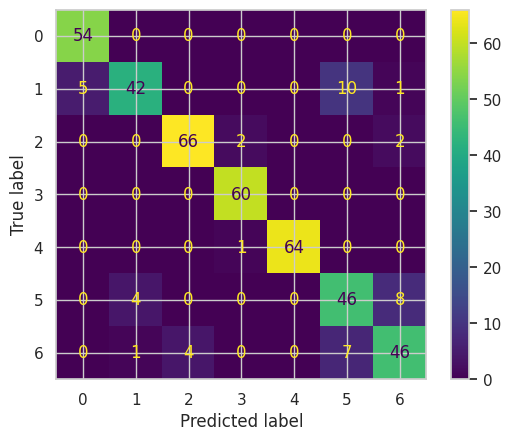

['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [60]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.linear_model import LogisticRegression

#Initializing the model
main_model = LogisticRegression(max_iter =1000, random_state = RANDOM_STATE)

# TODO: Predict on train, validation, and test.
#Training the data
main_model.fit(X_train_scaled, y_train)


#Making Predictions
y_val_prediction = main_model.predict(X_val_scaled)
y_test_prediction = main_model.predict(X_test_scaled)
y_train_prediction = main_model.predict(X_train_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import (accuracy_score, f1_score, classification_report)

#Calculating Accuracy
val_accuracy = accuracy_score(y_val, y_val_prediction)
test_accuracy = accuracy_score(y_test, y_test_prediction)
train_accuracy=accuracy_score(y_train, y_train_prediction)


print("Validation Accuracy: ", val_accuracy)
print("Testing Accuracy: ", test_accuracy)
print("Train Accuracy: ", train_accuracy)



#Calculating Micro-F1
val_f1 = f1_score(y_val, y_val_prediction, average="macro")
test_f1 = f1_score(y_test, y_test_prediction, average="macro")
train_f1 = f1_score(y_train, y_train_prediction, average="macro")

print("Validation Macro-F1: ", val_f1)
print("Testing Macro-F1: ", test_f1)
print("Train Macro-F1: ", train_f1)


print(classification_report(y_test, y_test_prediction))


# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,y_test_prediction)

plt.show()

print(main_encoder.classes_)

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:**

1.The Logistic Regression was chosen because it is a strong baseline for multi-class classification and it can be easily interpreted and also it works well with scaled numeric values.

2.Train accuracy=0.924/F1=0.922, Validation accuracy=0.879/F1=0.873, Test accuracy=0.894/F1=0.890.Comparing the Train vs Validation vs Test for accuracy and F1 ,the difference between between them is not wide ,it has a difference of approximately 3-4 points so the model is well-fitted.

3.From the confusion matrix, the obesity levels which are hard to tell apart are Normal_Weight and Overweight_Level_I ,and  Overweight_Level_I and Overweight_Level_II .This can happen because the mentioned categories are adjacent on the BMI spectrum  so the boundary between them is difficult to tell apart naturally as compared to more extreme classes like Obesity_Type_III which are more  clearly separated.

---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


In [61]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.


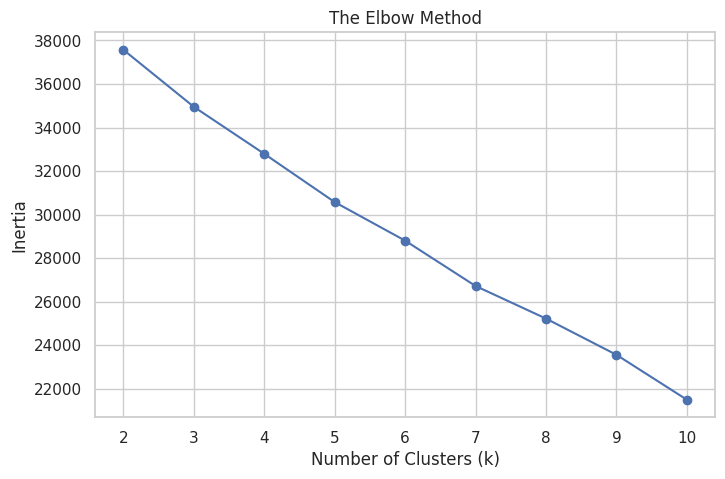

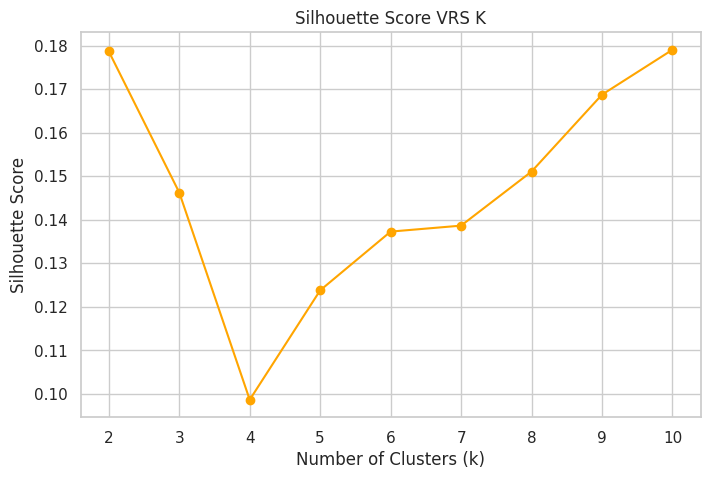

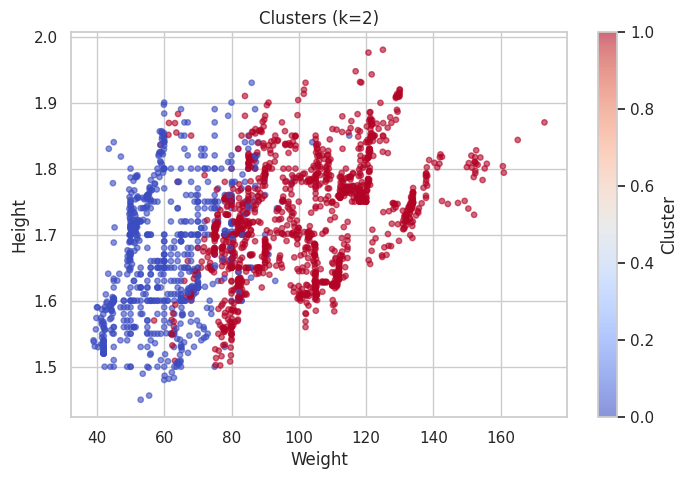

In [62]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = obesity.drop(['NObeyesdad'], axis=1)

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhou_scores =[]
k_range = range(2,11)


for k in k_range:
  km = KMeans(n_clusters =k, random_state = RANDOM_STATE, n_init=10)
  labels = km.fit_predict(X_cluster_scaled)
  inertias.append(km.inertia_)
  silhou_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(k_range,inertias,marker ="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("The Elbow Method")
plt.show()


plt.figure(figsize=(8,5))
plt.plot(k_range,silhou_scores,marker ="o", color = 'orange')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score VRS K")
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
chosen_k = 2
kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state = RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster_scaled)
plt.figure(figsize=(8,5))
plt.title('Clusters (k=2)')
plt.scatter(obesity['Weight'],obesity['Height'],c=cluster_labels,cmap='coolwarm', alpha=0.6, s=15)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title(f'Clusters (k={chosen_k})')
plt.colorbar(label='Cluster')
plt.show()




In [63]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?


#Some  clusters do not  map cleanly onto specific obesity levels.With our k being 2,
#they split individua;s into two broad groups(lower weight group and higher weight group).
#The loer weight group consistes of people who are mostly Insufficient_Weight and Normal_Weight
#and the higher weight group consists  mostly of the three Obesity_Type categories.Some categories
#like Overweight_Level_I and II are split almost evenly between both clusters.This indicates that K-means
#with only 2 clusters categorises individuals in two large groups based on their weight but it doesn't separate the obesity categories


NObeyesdad,0,1,2,3,4,5,6
row_0,,,,,,,
0,266,272,22,1,0,135,85
1,6,15,329,296,324,155,205


**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:**


1. I chose k using both evidence from my silhouette score and the elbow curve.From the elbow curve there wasn't a sharp bend for me to identify the k value. So I used the silhouette score plot to identify the k. To get the k value from the silhouette score plot, the k with the highest score is chosen.From the plot, the one with the highest score was 2 since it was appproximately 0.18.

2. The unsupervised clusters  partially resemble the real obesity levels.They agree  where Cluster 0 contains mostly Insufficient_Weight and Normal_Weight while Cluster 1 mostly contains the three Obesity_Type classes.They break down where Overweight_Level_I and Overweight_Level_II are split almost evenly across the two clusters.

3. In a real public-health setting where labels are expensive to collect, these clusters would be used to support low cost screening to help people know whether they have a high or low risk of being obese without needing an expert diagnosis.

---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:**


1.For supervised learning, the classifier learned how to map the features directly to the 7 specific obesity labels, as it had access to the true NObeyesdad values during training, which enabled it to achieve an accuracy score of 89% and some clear separation between most classes. On the other hand, the K-means algorithm, without any help or labels, only found the broad structure in the data based on feature similarity. However, the K-Means shows us that the natural and label-free structure in the data is simpler than all seven categories humans defined, which is something the classifier we used couldn’t tell us on its own.

2.Evaluating the regression task showed that it relied on continuous error metrics, including the RMSE and R², which measure how far our predictions are from the exact numerical values. It was noted that no correct discrete answer was given, just the closeness. However, evaluating the classification task using the obesity level, the accurate and macro-F1 methods were used to measure whether the predictions matched the same correct category. Regression evaluation revealed that it is about the magnitude of error, while classification evaluation is about the correctness and which specific categories get confused.

3. The biggest train vs test gap was in the Decision Tree regression model used, when the R**2 was 0.767, yet the validation amounted to -0.72 and -0.76, which is a huge gap indicating evidence of overfitting. However, the most effective fix to this would be reducing the max_depth to limit the tree’s capacity to easily memorize training noise, but instead force the trees or the model to learn more generalizable true patterns.




---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
